5
5
Log, "2025-09-18 14:52:59",        canoe, 1., "Installing monitor canoe"
Log, "2025-09-18 14:52:59",        canoe, 1.1., "Initialize IndexMap"
Log, "2025-09-18 14:52:59",         snap, 3., "Installing monitor snap"
Log, "2025-09-18 14:52:59",         snap, 3.1., "Initialize Thermodynamics"
Log, "2025-09-18 14:52:59",         snap, 3.1.1., "Enrolling vapor functions"
Log, "2025-09-18 14:52:59",         snap, 3.1.1.1., "Enrolling H2O vapor pressures"
Log, "2025-09-18 14:52:59",         snap, 3.1.2.1., "Enrolling NH3 vapor pressures"
Log, "2025-09-18 14:52:59",         snap, 4.1., "Initialize Decomposition"
Log, "2025-09-18 14:52:59",         snap, 5.1., "Initialize ImplicitSolver"
Log, "2025-09-18 14:52:59", microphysics, 7., "Installing monitor microphysics"
Log, "2025-09-18 14:52:59", microphysics, 7.1., "Initialize Microphysics"
Log, "2025-09-18 14:52:59",         harp, 9., "Installing monitor harp"
Log, "2025-09-18 14:52:59",         harp, 9.1., "Initialize Radiation"
Log, "2025-

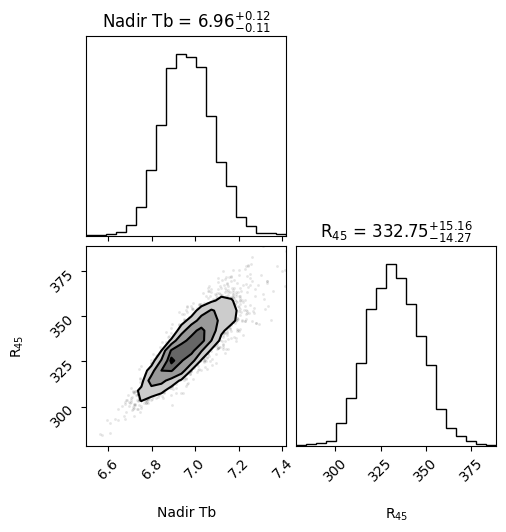

In [ ]:

import corner

#! /usr/bin/env python3
import numpy as np
import emcee
import sys, os
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm

from multiprocessing import Pool, current_process
import threading
import queue
import time

sys.path.append("build/python")
sys.path.append(".")
from canoe import def_species, load_configure
from canoe.snap import def_thermo
from canoe.athena import Mesh, ParameterInput, Outputs, MeshBlock
# from canoe.harp import radiation_band, radiation

def set_atmos_run_RT(qNH3: float, 
                     T0: float = 180.0, 
                     RHmax: float=1.0,
                     adlnNH3dlnP: float=0.0,
                     pmin: float = 0.0, 
                     pmax: float = 0.0,
                     jindex: int = 0
                     ):  
    ## construct atmos with a rh limit
    ## jindex is the index of current processer, starting from zero, will add to mb.jst in canoe backend 
    mb.construct_atmosphere(pin, qNH3, T0, RHmax, jindex,"dry", 2500, 500)


    ## do radiative transfer
    rad.cal_radiance(mb, mb.k_st, mb.j_st+jindex)
    tb = np.array([0.0] * 4 * nb)
    # print(tb.shape)
    for ib in range(nb):
        toa = rad.get_band(ib).get_toa()[0]
        tb[ib * 4 : ib * 4 + 4] = toa
    return tb


# Define the forward model simulator
def fwd_simulator(xNH3,theta, adlnNH3dlnP, Pmax , RHmax):
    tb=set_atmos_run_RT(xNH3, # NH3.ppmv
                     theta,       # Temperature
                     RHmax,         # RH_max_NH3
                     adlnNH3dlnP,        # adlnNH3/dlnP
                     1E-3,         # pmin [Pa]
                     Pmax,          # pmax [Pa]
                     0)
    print(xNH3,theta, adlnNH3dlnP, Pmax, RHmax)
    print(tb)
    return tb[::4], (tb[::4]-tb[3::4])/(tb[::4])*100
    # return  Nadir tb, R45

nx2 = 5  ## shall not be less than N_walkers, can be a little greater for safty.

## initialize Canoe
global pin
pin = ParameterInput()
pin.load_from_file("juno_mwr.inp")

vapors = pin.get_string("species", "vapor").split(", ")
clouds = pin.get_string("species", "cloud").split(", ")
tracers = pin.get_string("species", "tracer").split(", ")

def_species(vapors=vapors, clouds=clouds, tracers=tracers)
def_thermo(pin)

config = load_configure("juno_mwr.yaml")
# print(pin.get_real("problem", "qH2O.ppmv"))

pin.set_boolean("job","verbose", False)

print(pin.get_string("mesh","nx2"))
pin.set_string("mesh","nx2", f"{nx2}")

print(pin.get_string("mesh","nx2"))

mesh = Mesh(pin)
mesh.initialize(pin)

global mb, rad, nb
mb = mesh.meshblock(0)
rad = mb.get_rad()
nb = rad.get_num_bands()

# Assumed parameter values and uncertainties
theta_mean, theta_std = 175.65, 5.6         # Mean and standard deviation for theta
xNH3_mean, xNH3_std = 355.45, 38.8          # Mean and standard deviation for xNH3
adlnNH3dlnP_mean, adlnNH3dlnP_std = -0.08, 0.01  # Mean and standard deviation for adlnNH3dlnP
Pmax_mean, Pmax_std = 4.78, 1         # Mean and standard deviation for Pmax
RHmax_mean, RHmax_std= 0.62, 0.15
# Number of Monte Carlo steps
n_steps = 3000

# Arrays to store the results of R45 and brightness temperature
R45_samples = np.zeros((n_steps,6))
BT_samples = np.zeros((n_steps,6))

# Monte Carlo sampling
for i in range(n_steps):
    print(f"step {i} / {n_steps}")
    # Sample from normal distributions for each parameter
    theta = np.random.normal(theta_mean, theta_std)
    xNH3 = np.random.normal(xNH3_mean, xNH3_std)
    # adlnNH3dlnP = np.random.normal(adlnNH3dlnP_mean, adlnNH3dlnP_std)
    # Pmax = np.random.normal(Pmax_mean, Pmax_std) *1.E5
    adlnNH3dlnP = adlnNH3dlnP_mean
    Pmax = Pmax_mean*1.E5
    RHmax = RHmax_mean

    # Call the forward simulator
    BT, R45 = fwd_simulator(xNH3,theta,  adlnNH3dlnP, Pmax, RHmax)
    

    BT_samples[i,:] = BT
    R45_samples[i,:] = R45
# Save the results to an HDF5 file
with h5py.File('monte_carlo_dry_uniform_3000.h5', 'w') as h5file:
    h5file.create_dataset('R45_samples', data=R45_samples)
    h5file.create_dataset('BT_samples', data=BT_samples)

# Stack R45 and BT into a single array for the corner plot
data = np.vstack([R45_samples[:,2], BT_samples[:,2]]).T

# Generate a corner plot
figure = corner.corner(data, labels= ["Nadir Tb",r"R$_{45}$"], 
                       show_titles=True, title_kwargs={"fontsize": 12}, 
                       plot_datapoints=True, plot_density=True, 
                       fill_contours=True)

plt.show()


In [ ]:

import corner

#! /usr/bin/env python3
import numpy as np
import emcee
import sys, os
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm

from multiprocessing import Pool, current_process
import threading
import queue
import time

sys.path.append("./python")
sys.path.append(".")
from canoe import def_species, load_configure
from canoe.snap import def_thermo
from canoe.athena import Mesh, ParameterInput, Outputs, MeshBlock
# from canoe.harp import radiation_band, radiation

def set_atmos_run_RT(qNH3: float, 
                     T0: float = 180.0, 
                     RHmax: float=1.0,
                     adlnNH3dlnP: float=0.0,
                     pmin: float = 0.0, 
                     pmax: float = 0.0,
                     jindex: int = 0
                     ):  
    ## construct atmos with a rh limit
    ## jindex is the index of current processer, starting from zero, will add to mb.jst in canoe backend 
    mb.construct_atmosphere(pin, qNH3, T0, RHmax, jindex,"dry", 2500, 500)


    ## do radiative transfer
    rad.cal_radiance(mb, mb.k_st, mb.j_st+jindex)
    tb = np.array([0.0] * 4 * nb)
    # print(tb.shape)
    for ib in range(nb):
        toa = rad.get_band(ib).get_toa()[0]
        tb[ib * 4 : ib * 4 + 4] = toa
    return tb


# Define the forward model simulator
def fwd_simulator(xNH3,theta, adlnNH3dlnP, Pmax , RHmax):
    tb=set_atmos_run_RT(xNH3, # NH3.ppmv
                     theta,       # Temperature
                     RHmax,         # RH_max_NH3
                     adlnNH3dlnP,        # adlnNH3/dlnP
                     1E-3,         # pmin [Pa]
                     Pmax,          # pmax [Pa]
                     0)
    print(xNH3,theta, adlnNH3dlnP, Pmax, RHmax)
    print(tb)
    return tb[::4], (tb[::4]-tb[3::4])/(tb[::4])*100
    # return  Nadir tb, R45

nx2 = 5  ## shall not be less than N_walkers, can be a little greater for safty.

## initialize Canoe
global pin
pin = ParameterInput()
pin.load_from_file("juno_mwr.inp")

vapors = pin.get_string("species", "vapor").split(", ")
clouds = pin.get_string("species", "cloud").split(", ")
tracers = pin.get_string("species", "tracer").split(", ")

def_species(vapors=vapors, clouds=clouds, tracers=tracers)
def_thermo(pin)

config = load_configure("juno_mwr.yaml")
# print(pin.get_real("problem", "qH2O.ppmv"))

pin.set_boolean("job","verbose", False)

print(pin.get_string("mesh","nx2"))
pin.set_string("mesh","nx2", f"{nx2}")

print(pin.get_string("mesh","nx2"))

mesh = Mesh(pin)
mesh.initialize(pin)

global mb, rad, nb
mb = mesh.meshblock(0)
rad = mb.get_rad()
nb = rad.get_num_bands()

# Assumed parameter values and uncertainties
theta_mean, theta_std = 175.65, 5.6         # Mean and standard deviation for theta
xNH3_mean, xNH3_std = 355.45, 38.8          # Mean and standard deviation for xNH3
adlnNH3dlnP_mean, adlnNH3dlnP_std = -0.08, 0.01  # Mean and standard deviation for adlnNH3dlnP
Pmax_mean, Pmax_std = 4.78, 1         # Mean and standard deviation for Pmax
RHmax_mean, RHmax_std= 0.62, 0.15
# Number of Monte Carlo steps
n_steps = 3000

# Arrays to store the results of R45 and brightness temperature
R45_samples = np.zeros((n_steps,6))
BT_samples = np.zeros((n_steps,6))

# Monte Carlo sampling
for i in range(n_steps):
    print(f"step {i} / {n_steps}")
    # Sample from normal distributions for each parameter
    theta = np.random.normal(theta_mean, theta_std)
    xNH3 = np.random.normal(xNH3_mean, xNH3_std)
    # adlnNH3dlnP = np.random.normal(adlnNH3dlnP_mean, adlnNH3dlnP_std)
    # Pmax = np.random.normal(Pmax_mean, Pmax_std) *1.E5
    adlnNH3dlnP = adlnNH3dlnP_mean
    Pmax = Pmax_mean*1.E5
    RHmax = RHmax_mean

    # Call the forward simulator
    BT, R45 = fwd_simulator(xNH3,theta,  adlnNH3dlnP, Pmax, RHmax)
    

    BT_samples[i,:] = BT
    R45_samples[i,:] = R45
# Save the results to an HDF5 file
with h5py.File('monte_carlo_dry_uniform_rhmax_3000.h5', 'w') as h5file:
    h5file.create_dataset('R45_samples', data=R45_samples)
    h5file.create_dataset('BT_samples', data=BT_samples)

# Stack R45 and BT into a single array for the corner plot
data = np.vstack([R45_samples[:,2], BT_samples[:,2]]).T

# Generate a corner plot
figure = corner.corner(data, labels= ["Nadir Tb",r"R$_{45}$"], 
                       show_titles=True, title_kwargs={"fontsize": 12}, 
                       plot_datapoints=True, plot_density=True, 
                       fill_contours=True)

plt.show()


In [ ]:

import corner

#! /usr/bin/env python3
import numpy as np
import emcee
import sys, os
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm

from multiprocessing import Pool, current_process
import threading
import queue
import time

sys.path.append("../python")
sys.path.append(".")
from canoe import def_species, load_configure
from canoe.snap import def_thermo
from canoe.athena import Mesh, ParameterInput, Outputs, MeshBlock
# from canoe.harp import radiation_band, radiation

def set_atmos_run_RT(qNH3: float, 
                     T0: float = 180.0, 
                     RHmax: float=1.0,
                     adlnNH3dlnP: float=0.0,
                     pmin: float = 0.0, 
                     pmax: float = 0.0,
                     jindex: int = 0
                     ):  
    ## construct atmos with a rh limit

    Ts=mb.retrieve_Ts_given_T1bar(pin, qNH3, T0, RHmax, jindex,"dry", 2500, 500)

    ## construct moist atmosphere with bottom ts
    mb.construct_atmosphere_Ts(pin, qNH3, Ts, RHmax, jindex,"pseudo", 2500)

    ## modify the top humidity with a increment
    # mb.modify_dlnNH3dlnP_rhmax(adlnNH3dlnP, pmin, pmax, RHmax, jindex) 

    ## do radiative transfer
    rad.cal_radiance(mb, mb.k_st, mb.j_st+jindex)
    tb = np.array([0.0] * 4 * nb)
    # print(tb.shape)
    for ib in range(nb):
        toa = rad.get_band(ib).get_toa()[0]
        tb[ib * 4 : ib * 4 + 4] = toa
    return tb


# Define the forward model simulator
def fwd_simulator(xNH3,theta, adlnNH3dlnP, Pmax):
    tb=set_atmos_run_RT(xNH3, # NH3.ppmv
                     theta,       # Temperature
                     1.0,         # RH_max_NH3
                     adlnNH3dlnP,        # adlnNH3/dlnP
                     1E-3,         # pmin [Pa]
                     Pmax,          # pmax [Pa]
                     0)
    print(xNH3,theta, adlnNH3dlnP, Pmax)
    print(tb)
    return tb[::4], (tb[::4]-tb[3::4])/(tb[::4])*100
    # return  Nadir tb, R45

nx2 = 5  ## shall not be less than N_walkers, can be a little greater for safty.

## initialize Canoe
global pin
pin = ParameterInput()
pin.load_from_file("juno_mwr.inp")

vapors = pin.get_string("species", "vapor").split(", ")
clouds = pin.get_string("species", "cloud").split(", ")
tracers = pin.get_string("species", "tracer").split(", ")

def_species(vapors=vapors, clouds=clouds, tracers=tracers)
def_thermo(pin)

config = load_configure("juno_mwr.yaml")
# print(pin.get_real("problem", "qH2O.ppmv"))

pin.set_boolean("job","verbose", False)

print(pin.get_string("mesh","nx2"))
pin.set_string("mesh","nx2", f"{nx2}")

print(pin.get_string("mesh","nx2"))

mesh = Mesh(pin)
mesh.initialize(pin)

global mb, rad, nb
mb = mesh.meshblock(0)
rad = mb.get_rad()
nb = rad.get_num_bands()

# Assumed parameter values and uncertainties
theta_mean, theta_std = 175.65, 5.56         # Mean and standard deviation for theta
xNH3_mean, xNH3_std = 355.45, 38.8          # Mean and standard deviation for xNH3
adlnNH3dlnP_mean, adlnNH3dlnP_std = -0.6, 0.01  # Mean and standard deviation for adlnNH3dlnP
Pmax_mean, Pmax_std = 4.81, 1         # Mean and standard deviation for Pmax

# Number of Monte Carlo steps
n_steps = 3000

# Arrays to store the results of R45 and brightness temperature
R45_samples = np.zeros((n_steps,6))
BT_samples = np.zeros((n_steps,6))

# Monte Carlo sampling
for i in range(n_steps):
    print(f"step {i} / {n_steps}")
    # Sample from normal distributions for each parameter
    theta = np.random.normal(theta_mean, theta_std)
    xNH3 = np.random.normal(xNH3_mean, xNH3_std)
    # adlnNH3dlnP = np.random.normal(adlnNH3dlnP_mean, adlnNH3dlnP_std)
    # Pmax = np.random.normal(Pmax_mean, Pmax_std) *1.E5
    adlnNH3dlnP = adlnNH3dlnP_mean
    Pmax = Pmax_mean*1.E5

    # Call the forward simulator
    BT, R45 = fwd_simulator(xNH3,theta,  adlnNH3dlnP, Pmax)
    
    # Channel 3
    BT_samples[i,:] = BT
    R45_samples[i,:] = R45

# Save the results to an HDF5 file
with h5py.File('monte_carlo_moist_uniform_3000.h5', 'w') as h5file:
    h5file.create_dataset('R45_samples', data=R45_samples)
    h5file.create_dataset('BT_samples', data=BT_samples)

# Stack R45 and BT into a single array for the corner plot
data = np.vstack([R45_samples[:,2], BT_samples[:,2]]).T

# Generate a corner plot
figure = corner.corner(data, labels= ["Nadir Tb",r"R$_{45}$"], 
                       show_titles=True, title_kwargs={"fontsize": 12}, 
                       plot_datapoints=True, plot_density=True, 
                       fill_contours=True)

plt.show()
